#Analog image → detect hands → remove → return clean image

In [123]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from sklearn.model_selection import train_test_split

In [124]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
LABELS_PATH = DATA_DIR / "labels.csv"

BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cpu


In [125]:
df = pd.read_csv(LABELS_PATH)
print("Dataset size:", df.shape)
df.head()

Dataset size: (1000, 7)


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,15,38,21
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,1,8,27
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,5,5,2
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,9,7,39
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,8,3,48


In [126]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print(len(train_df), len(val_df))

800 200


In [127]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [128]:
class AnalogCleanerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        input_img = Image.open(row["analog_with_hands_path"]).convert("RGB")
        target_img = Image.open(row["analog_clean_path"]).convert("RGB")

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img

In [129]:
train_dataset = AnalogCleanerDataset(train_df, transform)
val_dataset = AnalogCleanerDataset(val_df, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [130]:
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = UNetBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = UNetBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = UNetBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = UNetBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = UNetBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = UNetBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = UNetBlock(64, 32)

        self.final = nn.Conv2d(32, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        x = self.pool1(e1)

        e2 = self.enc2(x)
        x = self.pool2(e2)

        e3 = self.enc3(x)
        x = self.pool3(e3)

        x = self.bottleneck(x)

        x = self.up3(x)
        x = torch.cat([x, e3], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, e1], dim=1)
        x = self.dec1(x)

        return torch.sigmoid(self.final(x))

In [131]:
model = UNet().to(DEVICE)

criterion = nn.L1Loss()  # חשוב! פחות blur

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [132]:
history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        pred = model(x)

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            loss = criterion(pred, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

Epoch 1 | Train 0.1785 | Val 0.0943
Epoch 2 | Train 0.0794 | Val 0.0683
Epoch 3 | Train 0.0696 | Val 0.0658
Epoch 4 | Train 0.0688 | Val 0.0647
Epoch 5 | Train 0.0661 | Val 0.0612
Epoch 6 | Train 0.0647 | Val 0.0576
Epoch 7 | Train 0.0626 | Val 0.0573
Epoch 8 | Train 0.0601 | Val 0.0549
Epoch 9 | Train 0.0619 | Val 0.0678
Epoch 10 | Train 0.0642 | Val 0.0582
Epoch 11 | Train 0.0600 | Val 0.0564
Epoch 12 | Train 0.0585 | Val 0.0572
Epoch 13 | Train 0.0585 | Val 0.0543
Epoch 14 | Train 0.0566 | Val 0.0517
Epoch 15 | Train 0.0553 | Val 0.0521


In [133]:
MODEL_PATH = BASE_DIR / "models" / "analog_cleaner_unet.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Saved:", MODEL_PATH)

Saved: clock_project\models\analog_cleaner_unet.pth


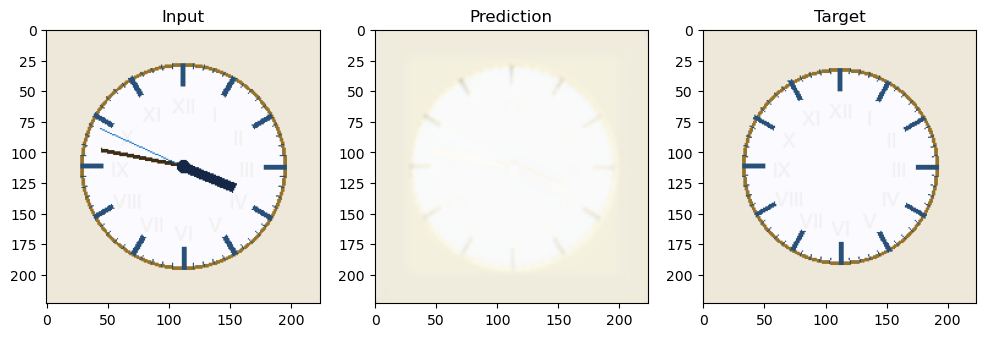

In [134]:
model.eval()

x, y = val_dataset[0]
x_in = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = model(x_in)

pred = pred.squeeze(0).cpu()

def show(img):
    return img.permute(1,2,0).numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(show(x))
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(show(pred))
plt.title("Prediction")

plt.subplot(1,3,3)
plt.imshow(show(y))
plt.title("Target")

plt.show()